## Цель работы: 
### освоить приемы генерации тестовых выборок и базовые линейные и вероятностные подходы к классификации.

## Задачи: 
### требуется выполнить классификацию тремя разными методами на самостоятельно сгенерированных входных данных указанного вида. Номера типов входных данных и алгоритмов классификации определяются по номеру варианта из таблицы 1. Пронумерованныеописания входных данных находятся в таблице 2, пронумерованные описания алгоритмов в таблице 3. Полные коды всех разработанных методов должны быть предоставлены для проверки; требуемые пояснения могут быть даны в виде комментариев к коду или отдельным документом любого нужного формата

## Задание 1. 
### По номеру варианта определить из таблицы 1 типы входных данных, которые надо программно сгенерировать для дальнейшей обработки, и номера алгоритмов, которые следует применить к этим данным.

#### Номера варианта: 6
#### Номер типа входных данных: 1,6,9
#### Номера алгоритмов: 2,3,5

## Задание 2. 
### Определить из таблицы 2 виды входных данных, которые должны быть обработаны, и сгенерировать их. В обучающую выборку включаются три указанные группы точек трехмерного пространства; каждую из классификаций следует провести три раза:
1. включив в один класс первую группу точек, в другой — вторую и третью;
2. включив в один класс первую и вторую группы точек, в другой — третью;
3. включив каждую группу точек в свой отдельный класс.

### Если выбранная библиотека алгоритмов не поддерживает классификацию с числом классов больше двух, дополнительное разбиение следует организовать вручную.

### Количество прецедентов должно задаваться одной из переменных программы, чтобы допустить лёгкое изменение в процессе тестирования; требуемое число прецедентов каждого типа совпадает.

1. Точки вида (a − 0.5, b, 0.5 + a + b + ε), где значения a, b, ε — независимые случайные числа, равномерно распределённые на отрезке [−1, 1]
2. Точки вида (a, 0.1b, 0.1a + 0.2b + 0.1ε), где значения a, b, ε — независимые случайные числа, нормально распределённые со средним значением 0 и среднеквадратическим отклонением 0.5
3. Точки трехмерного пространства вида (x, y, x2 +y), где значения x — нормально распределенные случайные числа со средним 1 и среднеквадратическим отклонением 1, значения y — случайные числа, равномерно распределенные по отрезку [−1, 1]

In [2]:
import random
import numpy as np
import pandas as pd

In [3]:
import seaborn as sns

In [4]:
import matplotlib.pyplot as plt

In [5]:
import re

In [6]:
#Группа точек А
def generate_group_A(sample_size: int) -> pd.DataFrame:
    a = np.random.uniform(low = -1, high = 1, size = sample_size)
    b = np.random.uniform(low = -1, high = 1, size = sample_size)
    e = np.random.uniform(low = -1, high = 1, size = sample_size)
    col1 = a-0.5
    col2 = b
    col3 = 0.5+a+b+e
    df = pd.DataFrame({
        'a-0.5': col1,
        'b': col2,
        '0.5+a+b+e': col3,
        'class': 'A'
    })
    return df

In [7]:
#Группа точек B
def generate_group_B(sample_size: int) -> pd.DataFrame:
    a = np.random.normal(loc=0, scale = 0.5, size = sample_size)
    b = np.random.normal(loc=0, scale = 0.5, size = sample_size)
    e = np.random.normal(loc=0, scale = 0.5, size = sample_size)
    col1 = a
    col2 = 0.1*b
    col3 = 0.1*a+0.2*b+0.1*e
    df = pd.DataFrame({
        'a': col1,
        '0.1*b': col2,
        '0.1*a+0.2*b+0.1*e': col3,
        'class': 'B'
    })
    return df

In [8]:
#Группа точек C
def generate_group_C(sample_size: int) -> pd.DataFrame:
    x = np.random.normal(loc = 1, scale = 1, size = sample_size)
    y = np.random.uniform(low = -1, high = 1, size = sample_size)
    xsq_y = x**2 + y
    col1 = x
    col2 = y
    col3 = xsq_y
    df = pd.DataFrame({
        'x': col1,
        'y': col2,
        'x**2 + y': col3,
        'class': 'C'
    })
    return df

In [9]:
#Диаграмма разброса
def generate_g(df: pd.DataFrame, columns: list, df_name: str) -> None:
    sns.set_theme(style="darkgrid")
    grid = sns.pairplot(
        df[columns], 
        kind = "reg", 
        diag_kind = 'kde', 
        plot_kws = {'line_kws':{'color':'m'}, 'scatter_kws': {'color': 'm'}},
        height = 3
        )
    grid.fig.suptitle(f"Pairplot for: {', '.join(columns)}", y=1.02)

    file_name = f"data_visualization_{df_name}.png"
    
    grid.savefig(fname=file_name, bbox_inches='tight')
    plt.show()


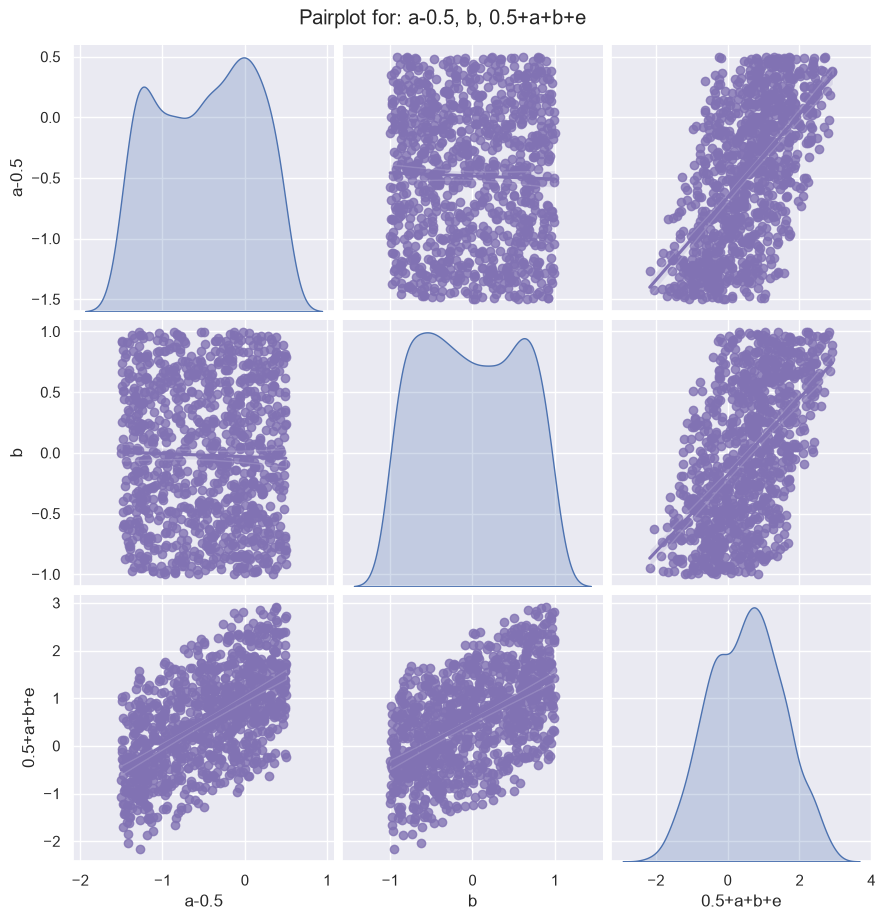

In [10]:
df_A = generate_group_A(sample_size=1000)
cols_A = ['a-0.5', 'b', '0.5+a+b+e']
generate_g(df_A, cols_A, 'A')

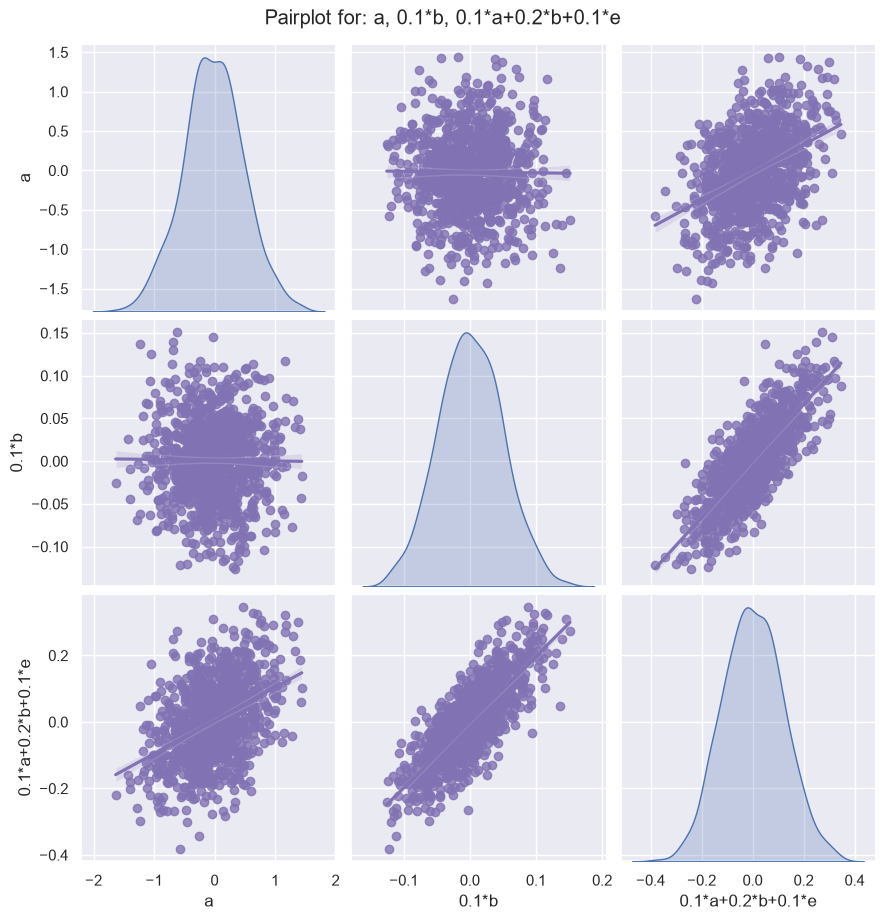

In [11]:
df_B = generate_group_B(sample_size=1000)
cols_B = ['a','0.1*b','0.1*a+0.2*b+0.1*e']
generate_g(df_B, cols_B,'B')

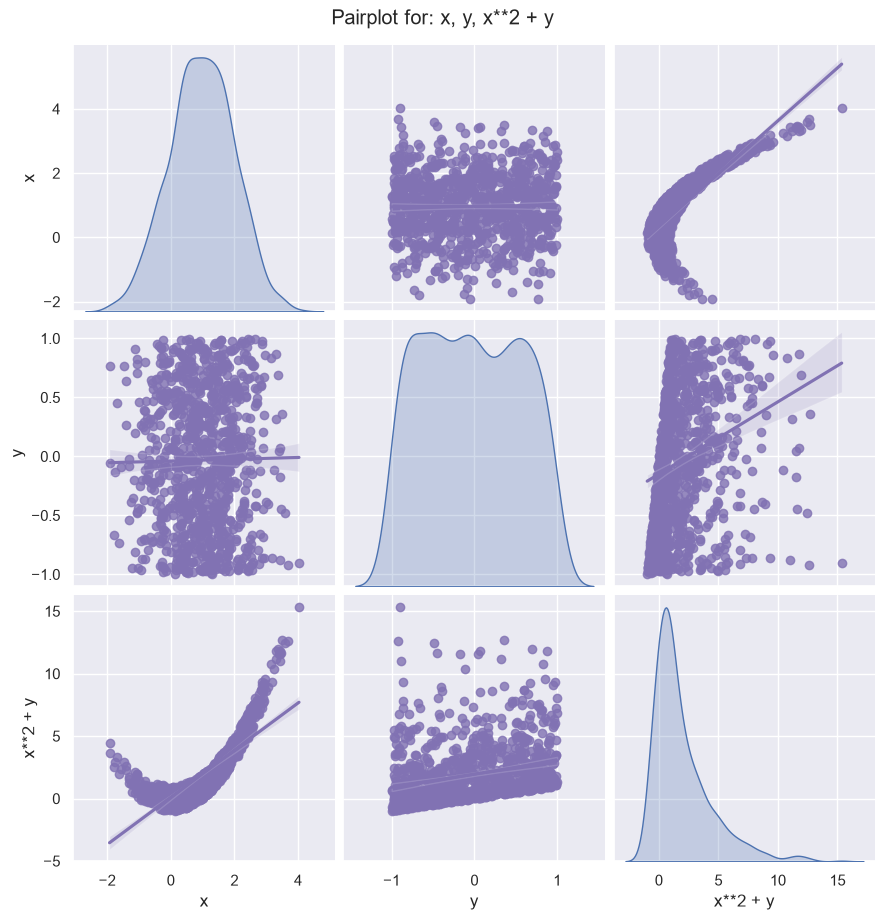

In [12]:
df_C = generate_group_C(sample_size=1000)
cols_C = ['x','y','x**2 + y']
generate_g(df_C, cols_C, 'C')

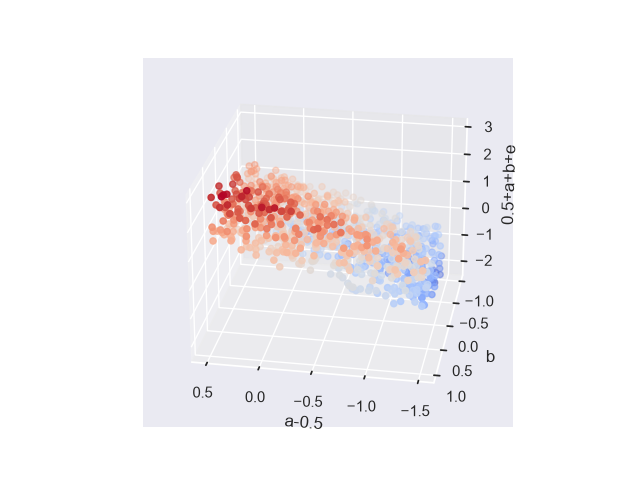

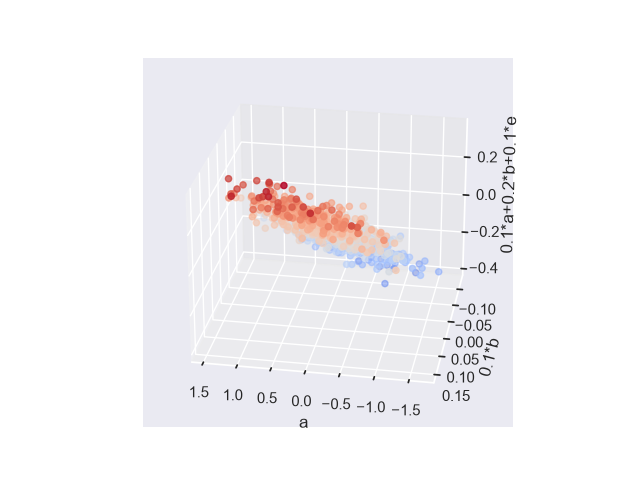

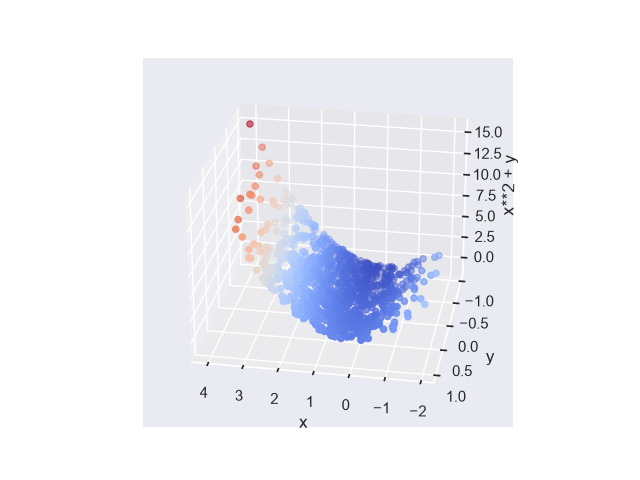

In [13]:
%matplotlib widget
def fig_3d(df: pd.DataFrame, columns: list[str], df_name: str)->None:
    x,y,z = columns
    ax = plt.figure().add_subplot(projection='3d')
    ax.scatter(df[x],df[y],df[z], c=df[z],cmap='coolwarm')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_zlabel(z)
    ax.view_init(elev=25, azim=100, roll=0)

    filename = f"3d_visualization_{df_name}.png"
    plt.savefig(fname=filename)
    plt.show()

fig_3d(df_A, cols_A,'A')
fig_3d(df_B, cols_B,'B')
fig_3d(df_C, cols_C,'C')

Index(['a-0.5', 'b', '0.5+a+b+e', 'class'], dtype='str')
Index(['a', '0.1*b', '0.1*a+0.2*b+0.1*e', 'class'], dtype='str')
Index(['x', 'y', 'x**2 + y', 'class'], dtype='str')


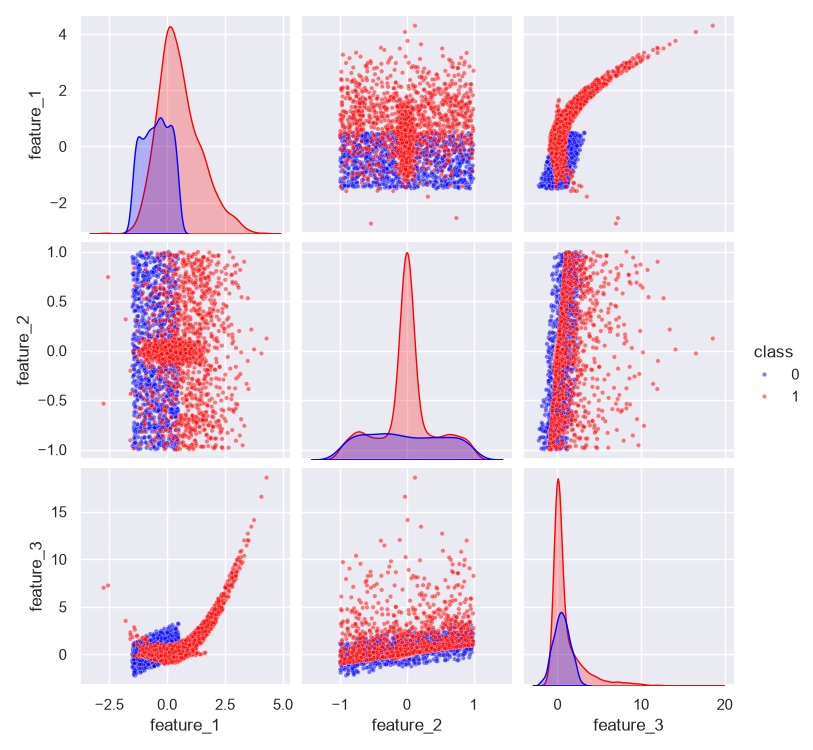

In [14]:
#Бинарная классификация (A vs B+C)

df_A = generate_group_A(1000)
df_B = generate_group_B(1000)
df_C = generate_group_C(1000)

print(df_A.columns)
print(df_B.columns)
print(df_C.columns)

common_columns = ['feature_1', 'feature_2', 'feature_3', 'class']
df_A_renamed = df_A.set_axis(common_columns, axis=1)
df_B_renamed = df_B.set_axis(common_columns, axis=1)
df_C_renamed = df_C.set_axis(common_columns, axis=1)

df_A_renamed['class'] = 0
df_B_renamed['class'] = 1
df_C_renamed['class'] = 1


df_binary_a_vs_bc = pd.concat([df_A_renamed, df_B_renamed, df_C_renamed], ignore_index=True)

#Визуализация
grid= sns.pairplot(
    df_binary_a_vs_bc,
    hue='class',
    palette = {0: 'blue', 1: 'red'},
    plot_kws = {'alpha': 0.5, 's': 10},
    diag_kind='kde'
)
grid.fig.suptitle("A vs B+C", y=1.02)
file_name = f"data_visualization_a_vs_bc.png"
grid.savefig(fname=file_name, bbox_inches='tight')
plt.show()


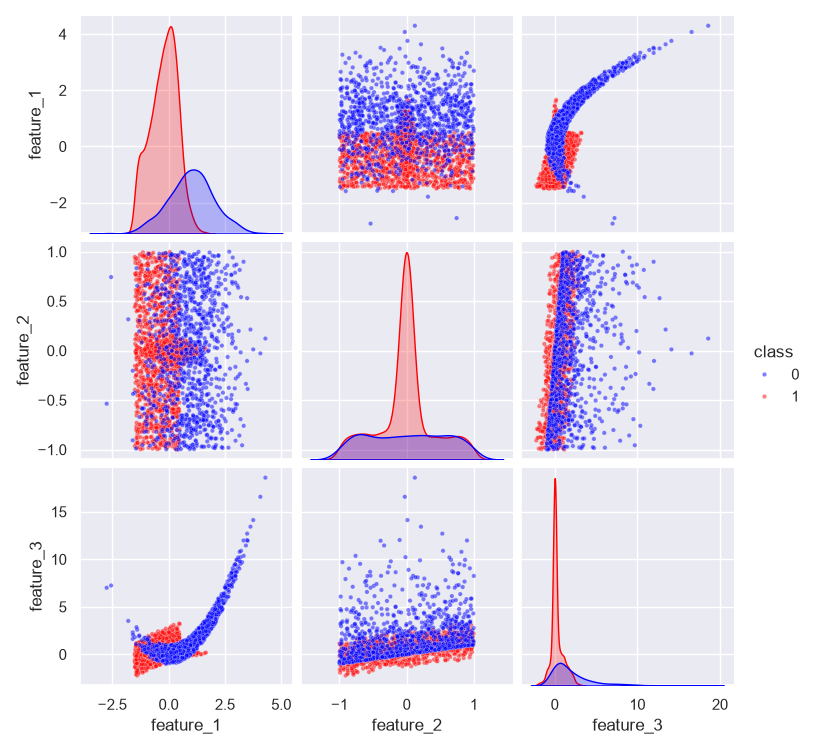

In [15]:
#Бинарная классификация (A+B vs C)

df_A_renamed['class'] = 1
df_B_renamed['class'] = 1
df_C_renamed['class'] = 0


df_binary_ab_vs_c = pd.concat([df_A_renamed, df_B_renamed, df_C_renamed], ignore_index=True)
grid= sns.pairplot(
    df_binary_ab_vs_c,
    hue='class',
    palette = {0: 'blue', 1: 'red'},
    plot_kws = {'alpha': 0.5, 's': 10},
    diag_kind='kde'
)
grid.fig.suptitle("A+B vs C", y=1.02)
file_name = f"data_visualization_ab_vs_c.png"
grid.savefig(fname=file_name, bbox_inches='tight')
plt.show()


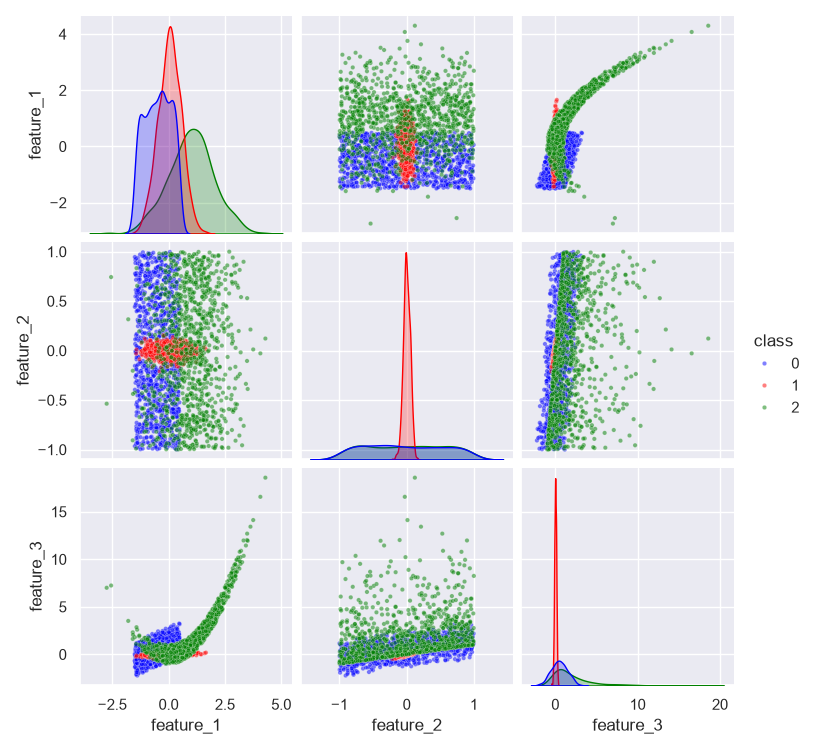

In [16]:
# Многоклассовая классификация (A vs B vs C)
df_A_renamed['class'] = 0
df_B_renamed['class'] = 1
df_C_renamed['class'] = 2


df_multi_a_vs_b_vs_c = pd.concat([df_A_renamed, df_B_renamed, df_C_renamed], ignore_index=True)

grid= sns.pairplot(
    df_multi_a_vs_b_vs_c,
    hue='class',
    palette = {0: 'blue', 1: 'red', 2: 'green'},
    plot_kws = {'alpha': 0.5, 's': 10},
    diag_kind='kde'
)
grid.fig.suptitle("A vs B vs C", y=1.02)
file_name = f"data_visualization_a_vs_b_vs_c.png"
grid.savefig(fname=file_name, bbox_inches='tight')
plt.show()

## Задание 3. 
### Определить по таблице 3 методы обработки данных. Следует обработать каждую из выборок двумя указанными методами и сравнить качество полученных моделей (как минимум, precision и recall для каждого из классов). Значения настроечных коэффициентов, если они требуются, следует выбрать самостоятельно; нулевые значения этих коэффициентов не допускаются.

1. Метод опорных векторов
2. Логистическая регрессия
3. Линейный дискриминант Фишера

In [17]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split


In [18]:
#Разделение выборок на train/split
def train_test(df: pd.DataFrame):
    X = df.drop(columns=['class'])
    y = df['class']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    return X_train, X_test, y_train, y_test

In [19]:
#1)AvsB+C
X_train_A_BC, X_test_A_BC, y_train_A_BC, y_test_A_BC = train_test(df = df_binary_a_vs_bc)
#2)A+B vs C
X_train_AB_C, X_test_AB_C, y_train_AB_C, y_test_AB_C = train_test(df = df_binary_ab_vs_c)
#3)A vs B vs C
X_train_A_B_C, X_test_A_B_C, y_train_A_B_C, y_test_A_B_C = train_test(df = df_multi_a_vs_b_vs_c)

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [21]:
#Обучаем модели и сравниваем качество
def evaluate_model(models: dict, X_train, X_test, y_train, y_test, dataset_name: str) -> pd.DataFrame:
    results =[]

    is_multiclass = len(y_train.unique())>2
    average_param = 'weighted' if is_multiclass else 'binary'

    for name, model in models.items():
        model.fit(X_train,y_train)

        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average = average_param, zero_division=0)
        rec = recall_score(y_test, y_pred, average=average_param, zero_division= 0)
        f1 = f1_score(y_test, y_pred, average=average_param, zero_division= 0)

        results.append({
            'Task': dataset_name,
            'Model': name,
            'Accuracy': round(acc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1': round(f1, 4)
        })
    return pd.DataFrame(results)



In [25]:
def get_fresh_models():
    return {
        'Linear SVC': LinearSVC(max_iter=2000),         #max_iter задаёт верхнюю границу — максимальное число итераций, которое алгоритм выполнит перед тем, как остановиться
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'Linear Discriminant': LinearDiscriminantAnalysis()
    }

#1) A vs B+C
models_1 = get_fresh_models()
res_1 = evaluate_model(models_1, X_train_A_BC, X_test_A_BC, y_train_A_BC, y_test_A_BC, dataset_name = "A vs B+C")

#2) A+B vs C
models_2 = get_fresh_models()
res_2 = evaluate_model(models_2, X_train_AB_C, X_test_AB_C, y_train_AB_C, y_test_AB_C, dataset_name = "A+B vs C")

#3) A vs B vs C
models_3 = get_fresh_models()
res_3 = evaluate_model(models_3, X_train_A_B_C, X_test_A_B_C, y_train_A_B_C, y_test_A_B_C, dataset_name = "A vs B vs C")

df_all_results = pd.concat([res_1, res_2, res_3], ignore_index=True)

df_all_results.style.highlight_max(
    subset = ['Accuracy', 'Precision', 'Recall', 'F1'],
    color = 'green',
    axis = 0
)

,Task,Model,Accuracy,Precision,Recall,F1
0,A vs B+C,Linear SVC,0.791700,0.831700,0.862800,0.847000
1,A vs B+C,Logistic Regression,0.795000,0.835700,0.862800,0.849100
2,A vs B+C,Linear Discriminant,0.790000,0.834500,0.855400,0.844800
3,A+B vs C,Linear SVC,0.826700,0.794600,0.987100,0.880500
4,A+B vs C,Logistic Regression,0.833300,0.807700,0.974200,0.883200
5,A+B vs C,Linear Discriminant,0.828300,0.797500,0.984500,0.881200
6,A vs B vs C,Linear SVC,0.703300,0.713700,0.703300,0.701400
7,A vs B vs C,Logistic Regression,0.718300,0.732700,0.718300,0.717300
8,A vs B vs C,Linear Discriminant,0.736700,0.760500,0.736700,0.738100


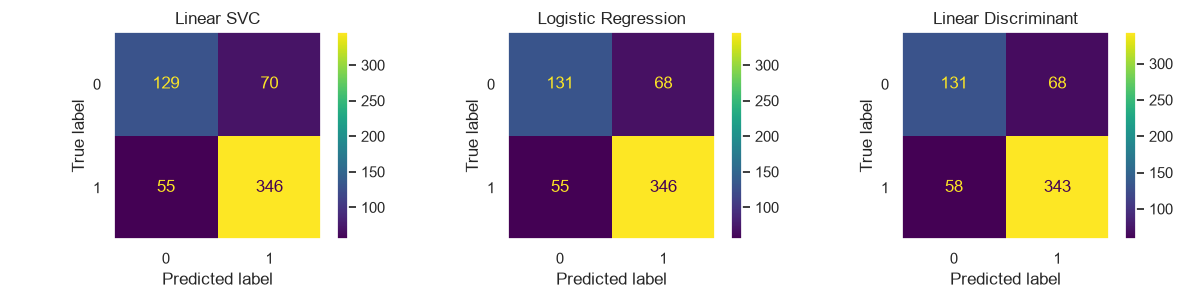

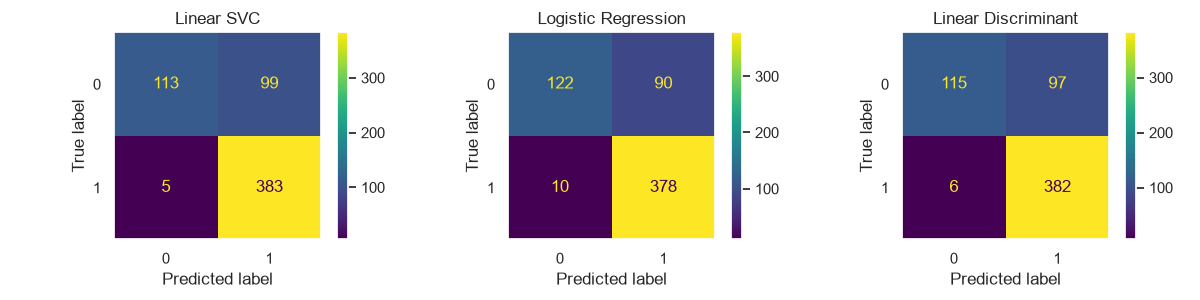

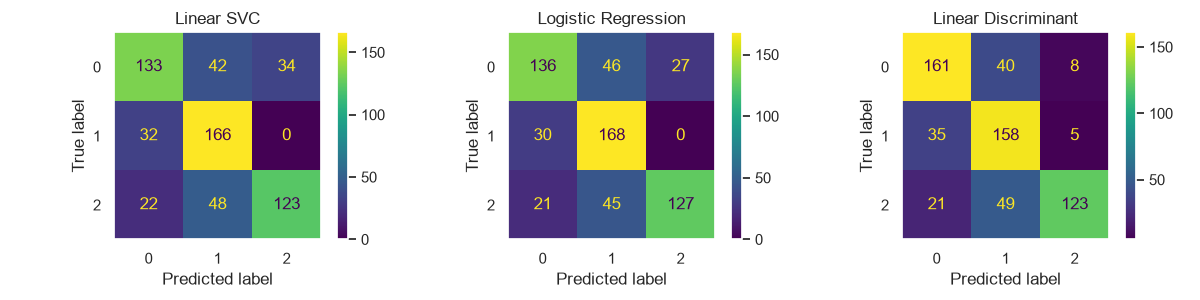

In [23]:
#Графики сравнения
from sklearn.metrics import ConfusionMatrixDisplay

def plot_conf_matr(models: dict, X_test, y_test, title: str):
    #Создаем сетку из подграффиков с 1 строкой и длиной в количество моделей
    fig, axes = plt.subplots(1, len(models), figsize = (4*len(models), 3))
    
    #цикол по моделям и подграфикам. zipсвязывает каждую ось координат с соответствующей парой из названия и модели
    for ax, (name, model) in zip(axes, models.items()):
        ax.grid(False)
        ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax)
        ax.set_title(name)
    
    plt.tight_layout()
    plt.suptitle(f"Confusion Matrices: {title}", y=1.05)
    clean_title = re.sub(r'[^\w\.-]', '_', title)
    file_name = f"confusion_matrix_{clean_title}.png"
    plt.savefig(file_name, bbox_inches='tight', dpi=300)
    plt.show()

plot_conf_matr(models_1, X_test_A_BC, y_test_A_BC, "A vs B+C")
plot_conf_matr(models_2,  X_test_AB_C,  y_test_AB_C, "A+B vs C")
plot_conf_matr(models_3,  X_test_A_B_C,  y_test_A_B_C, "A vs B vs C")


## Задание 4. 
### Сгенерировать новую выборку данных такого же размера, включив в один класс первую группу прецедентов, в другой — вторую и третью (так, как в задании 2 была получена первая из тестовых выборок). Послее этого сравнить точность всех моделей на новой выборке и первой из прежних. Сделать вывод о сохранении точностных характеристик каждой из моделей.

In [24]:
N_ITERATIONS = 1000
all_results = []

for i in range(N_ITERATIONS):
    #Генерируем A vs B+C
    df_A = generate_group_A(1000)
    df_B = generate_group_B(1000)
    df_C = generate_group_C(1000)

    common_columns = ['feature_1', 'feature_2', 'feature_3', 'class']
    df_A_renamed = df_A.set_axis(common_columns, axis=1)
    df_B_renamed = df_B.set_axis(common_columns, axis=1)
    df_C_renamed = df_C.set_axis(common_columns, axis=1)

    df_A_renamed['class'] = 0
    df_B_renamed['class'] = 1
    df_C_renamed['class'] = 1

    df_binary_compare = pd.concat([df_A_renamed, df_B_renamed, df_C_renamed], ignore_index=True)
    
    #Разбиение на train/test
    X_train_compare, X_test_compare, y_train_compare, y_test_compare = train_test(df = df_binary_compare)

    models = get_fresh_models()
    res = evaluate_model(models, X_train_compare, X_test_compare, y_train_compare, y_test_compare, dataset_name = "A vs B+C")
    all_results.append(res)

#Объединяем результаты всех запусков в df
df_all_iterations = pd.concat(all_results, ignore_index = True)

# Считаем mean & std
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
stats = df_all_iterations.groupby('Model')[metrics].agg(['mean', 'std'])
df_summary = pd.DataFrame(index = stats.index)

for metric in metrics:
    mean_series = stats[metric]['mean']
    std_series = stats[metric]['std']

    df_summary[metric] = mean_series.map('{:.4f}'.format) + " ± " + std_series.map('{:.4f}'.format)

df_summary


,Accuracy,Precision,Recall,F1
Model,,,,
Linear Discriminant,0.7977 ± 0.0156,0.8308 ± 0.0184,0.8751 ± 0.0175,0.8522 ± 0.0124
Linear SVC,0.7965 ± 0.0156,0.8249 ± 0.0186,0.8824 ± 0.0168,0.8525 ± 0.0123
Logistic Regression,0.7966 ± 0.0157,0.8258 ± 0.0183,0.8811 ± 0.0168,0.8524 ± 0.0124


## Вывод о сохранении точностных характеристик:
### Было:

| Task | Model | Accuracy | Precision | Recall | F1 |
| :--- | :--- | :---: | :---: | :---: | :---: |
| A vs B+C | Linear SVC | 0.8167 | 0.8598 | 0.8804 | 0.8700 |
| A vs B+C | Logistic Regression | 0.8150 | 0.8595 | 0.8780 | 0.8686 |
| A vs B+C | Linear Discriminant | 0.8167 | 0.8615 | 0.8780 | 0.8697 |

### Среднее при 1000 итераций:
| Model | Accuracy | Precision | Recall | F1 |
| :--- | :---: | :---: | :---: | :---: |
| **Linear Discriminant** | 0.7989 ± 0.0159 | 0.8324 ± 0.0185 | 0.8751 ± 0.0177 | 0.8530 ± 0.0125 |
| **Linear SVC** | 0.7978 ± 0.0161 | 0.8266 ± 0.0188 | 0.8822 ± 0.0173 | 0.8533 ± 0.0126 |
| **Logistic Regression** | 0.7977 ± 0.0161 | 0.8274 ± 0.0186 | 0.8809 ± 0.0172 | 0.8531 ± 0.0126 |

### Грубо оценивая, точностные характеристики при первой прогонке лежат в пределах погрешности среднего значения


Контрольные вопросы
1. Какие из перечисленных алгоритмов обработки устойчивы к выбросам?

LDA неуст

LogReg в целом устойчива но выбросы влияют

SVC устойчив

2. Какие из перечисленных алгоритмов обработки удовлетворяют критерию максимального
правдоподобия?

SVC - геом, остальные удовл

3. Какие из созданных выборок линейно отделимы?

Никакие, если поставить жесткий зазор C=1e7, то аккураси будет меньше 100%

4. Существуют ли какие-либо приёмы обеспечения линейной отделимости выборок?

Замена перем, kernel trick, feature engineering, deep learning, переход в другие координаты

5. Как можно оценить требуемое число компонентов в байесовской смеси?

BIC, AIC - критерии для оценки
